In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shamithaks/cricket-dataset/t20_cricket_match_score_prediction.csv


In [5]:

import matplotlib
import matplotlib.pyplot as plt
 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import xgboost as xgb
 
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
 
RNG = 42
np.random.seed(RNG)

In [13]:
df = pd.read_csv("/kaggle/input/datasets/shamithaks/cricket-dataset/t20_cricket_match_score_prediction.csv")
df = df.rename(columns={"Predicted Score": "Final Score"})
df = df.sort_values("Match ID").reset_index(drop=True)
 
print("Shape:", df.shape)
print(df.columns)
print(df.head())
print(df.dtypes)
print("Duplicates:", df.duplicated().sum())
print("Nulls:\n", df.isnull().sum())
print(df.describe())

Shape: (1500, 9)
Index(['Match ID', 'Overs Played', 'Wickets Lost', 'Run Rate', 'Home/Away',
       'Opponent Strength', 'Pitch Condition', 'Weather', 'Final Score'],
      dtype='object')
   Match ID  Overs Played  Wickets Lost  Run Rate Home/Away  \
0         1             7             1     11.04      Away   
1         2            20            10     11.87      Home   
2         3            15             7      6.14      Home   
3         4            11             8      8.84      Home   
4         5             8             0      9.56      Home   

   Opponent Strength Pitch Condition Weather  Final Score  
0                  3         Bowling   Sunny           82  
1                  5         Bowling   Sunny          204  
2                  7        Balanced   Sunny          105  
3                  9         Batting  Cloudy          121  
4                  2        Balanced   Sunny          104  
Match ID               int64
Overs Played           int64
Wickets Lost  

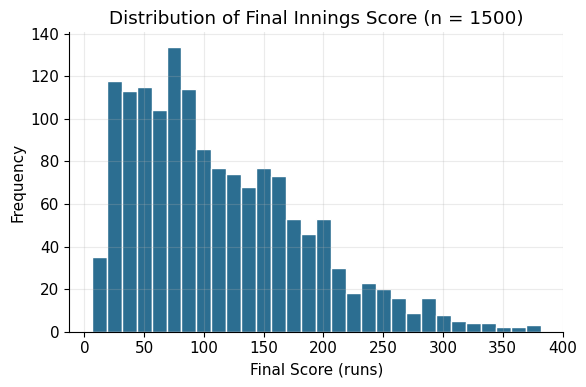

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df['Final Score'], bins=30, color="#2c6e91", edgecolor="white")
ax.set_title("Distribution of Final Innings Score (n = 1500)")
ax.set_xlabel("Final Score (runs)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

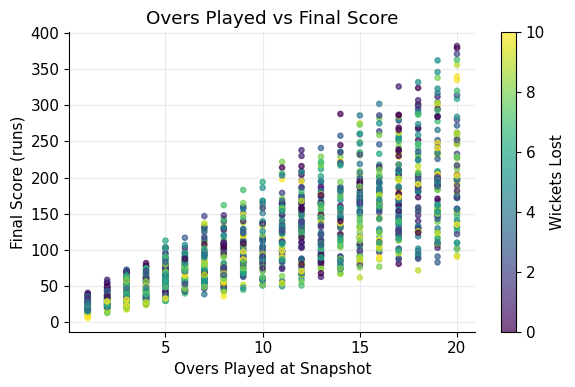

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(df['Overs Played'], df['Final Score'], c=df['Wickets Lost'],
                 cmap="viridis", s=14, alpha=0.7)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("Wickets Lost")
ax.set_title("Overs Played vs Final Score")
ax.set_xlabel("Overs Played at Snapshot")
ax.set_ylabel("Final Score (runs)")
plt.tight_layout()
plt.show()

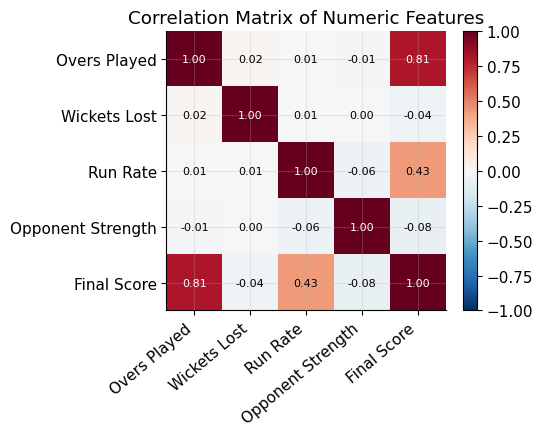

In [16]:
num_cols = ["Overs Played", "Wickets Lost", "Run Rate", "Opponent Strength", "Final Score"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=40, ha="right")
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr.iloc[i, j]) > 0.5 else "black", fontsize=8)
ax.set_title("Correlation Matrix of Numeric Features")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [17]:
data = df.copy()
 
data["Overs Remaining"] = 20 - data["Overs Played"]
data["Wickets in Hand"] = 10 - data["Wickets Lost"]
data["Current Runs Est"] = (data["Run Rate"] * data["Overs Played"]).round(1)
data["Is Home"] = (data["Home/Away"] == "Home").astype(int)
 
pitch_map = {"Bowling": -1, "Balanced": 0, "Batting": 1}
data["Pitch Score"] = data["Pitch Condition"].map(pitch_map)
 
data = pd.get_dummies(data, columns=["Weather"], prefix="Wx", drop_first=True)
 
feature_cols = ["Overs Played", "Overs Remaining", "Wickets Lost", "Wickets in Hand",
                 "Run Rate", "Current Runs Est", "Is Home", "Opponent Strength",
                 "Pitch Score"] + [c for c in data.columns if c.startswith("Wx_")]
 
print("Feature columns:", feature_cols)
data.head()

Feature columns: ['Overs Played', 'Overs Remaining', 'Wickets Lost', 'Wickets in Hand', 'Run Rate', 'Current Runs Est', 'Is Home', 'Opponent Strength', 'Pitch Score', 'Wx_Overcast', 'Wx_Sunny']


,Match ID,Overs Played,Wickets Lost,Run Rate,Home/Away,Opponent Strength,Pitch Condition,Final Score,Overs Remaining,Wickets in Hand,Current Runs Est,Is Home,Pitch Score,Wx_Overcast,Wx_Sunny
0,1,7,1,11.04,Away,3,Bowling,82,13,9,77.3,0,-1,False,True
1,2,20,10,11.87,Home,5,Bowling,204,0,0,237.4,1,-1,False,True
2,3,15,7,6.14,Home,7,Balanced,105,5,3,92.1,1,0,False,True
3,4,11,8,8.84,Home,9,Batting,121,9,2,97.2,1,1,False,False
4,5,8,0,9.56,Home,2,Balanced,104,12,10,76.5,1,0,False,True


In [18]:
n = len(data)
split = int(n * 0.8)
train, test = data.iloc[:split].copy(), data.iloc[split:].copy()
print(f"Train size: {len(train)}, Test size: {len(test)}")
 
y_train, y_test = train["Final Score"].values, test["Final Score"].values
X_train, X_test = train[feature_cols].values, test[feature_cols].values

Train size: 1200, Test size: 300


# **1.Simple Exponential Smoothing**

In [19]:
ses_model = SimpleExpSmoothing(y_train, initialization_method="estimated").fit(optimized=True)
alpha = ses_model.model.params["smoothing_level"]
print(f"SES optimal alpha = {alpha:.4f}")
 
level = ses_model.level[-1]
ses_forecast_roll = []
for actual in y_test:
    ses_forecast_roll.append(level)
    level = alpha * actual + (1 - alpha) * level
ses_forecast_roll = np.array(ses_forecast_roll)

SES optimal alpha = 0.0000


# **2. Multiple Linear Regression**

In [20]:
mlr = LinearRegression().fit(X_train, y_train)
mlr_forecast = mlr.predict(X_test)
 
coef_table = pd.DataFrame({"Feature": feature_cols, "Coefficient": mlr.coef_}).sort_values(
    "Coefficient", key=abs, ascending=False)
print("MLR coefficients:\n", coef_table)
print("MLR intercept:", mlr.intercept_)

MLR coefficients:
               Feature  Coefficient
8         Pitch Score    22.764116
9         Wx_Overcast   -12.454471
10           Wx_Sunny     4.523896
5    Current Runs Est     0.998383
7   Opponent Strength    -0.871510
3     Wickets in Hand     0.765777
2        Wickets Lost    -0.765777
4            Run Rate    -0.206574
6             Is Home     0.159749
0        Overs Played    -0.081864
1     Overs Remaining     0.081864
MLR intercept: 20.019299842231575


# **3.XGBoost**

In [21]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=RNG
)
xgb_model.fit(X_train, y_train)
xgb_forecast = xgb_model.predict(X_test)
 
imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("XGB feature importance:\n", imp)

XGB feature importance:
 Current Runs Est     0.549613
Overs Played         0.222548
Pitch Score          0.124580
Run Rate             0.049073
Wx_Overcast          0.030770
Wx_Sunny             0.011096
Wickets Lost         0.005335
Opponent Strength    0.003296
Wickets in Hand      0.003024
Overs Remaining      0.000557
Is Home              0.000109
dtype: float32


In [22]:
def metrics(y_true, y_pred, name):
    mad = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MAD (MAE)": mad, "MSE": mse, "RMSE": rmse,
             "MAPE (%)": mape, "R2": r2}
 
results = pd.DataFrame([
    metrics(y_test, ses_forecast_roll, "Simple Exponential Smoothing"),
    metrics(y_test, mlr_forecast, "Multiple Linear Regression"),
    metrics(y_test, xgb_forecast, "XGBoost Regressor"),
])
results = results.set_index("Model").round(3)
print("=== ERROR METRICS (test set) ===")
print(results)

=== ERROR METRICS (test set) ===
                              MAD (MAE)       MSE    RMSE  MAPE (%)     R2
Model                                                                     
Simple Exponential Smoothing     56.243  4905.042  70.036    88.589 -0.002
Multiple Linear Regression        8.270   133.638  11.560    13.396  0.973
XGBoost Regressor                 2.353    12.012   3.466     2.425  0.998


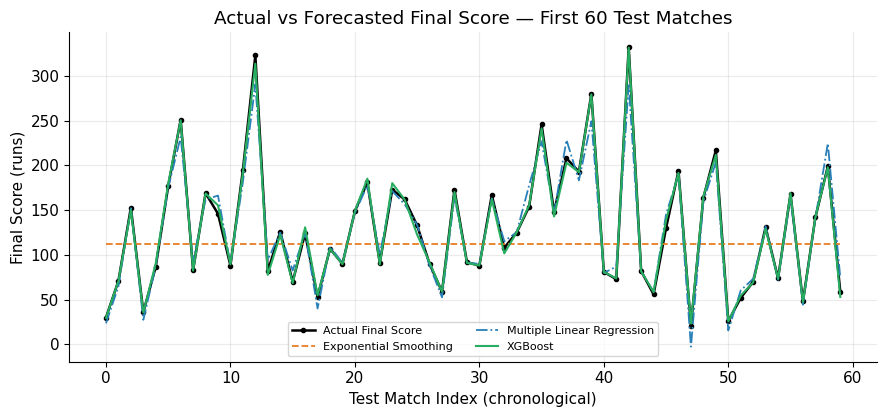

In [23]:
N_SHOW = 60
idx = np.arange(N_SHOW)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(idx, y_test[:N_SHOW], label="Actual Final Score", color="black",
        linewidth=1.8, marker='o', markersize=3)
ax.plot(idx, ses_forecast_roll[:N_SHOW], label="Exponential Smoothing",
        color="#e67e22", linewidth=1.3, linestyle="--")
ax.plot(idx, mlr_forecast[:N_SHOW], label="Multiple Linear Regression",
        color="#2980b9", linewidth=1.3, linestyle="-.")
ax.plot(idx, xgb_forecast[:N_SHOW], label="XGBoost", color="#27ae60", linewidth=1.5)
ax.set_title("Actual vs Forecasted Final Score — First 60 Test Matches")
ax.set_xlabel("Test Match Index (chronological)")
ax.set_ylabel("Final Score (runs)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

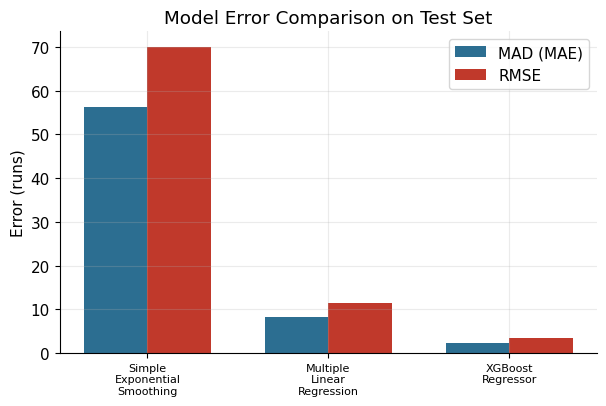

In [24]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
metrics_to_plot = ["MAD (MAE)", "RMSE"]
width = 0.35
xlabels = results.index
x = np.arange(len(xlabels))
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + i * width - width / 2, results[m], width, label=m,
           color=["#2c6e91", "#c0392b"][i])
ax.set_xticks(x)
ax.set_xticklabels([lbl.replace(" ", "\n") for lbl in xlabels], fontsize=8)
ax.set_ylabel("Error (runs)")
ax.set_title("Model Error Comparison on Test Set")
ax.legend()
plt.tight_layout()
plt.show()

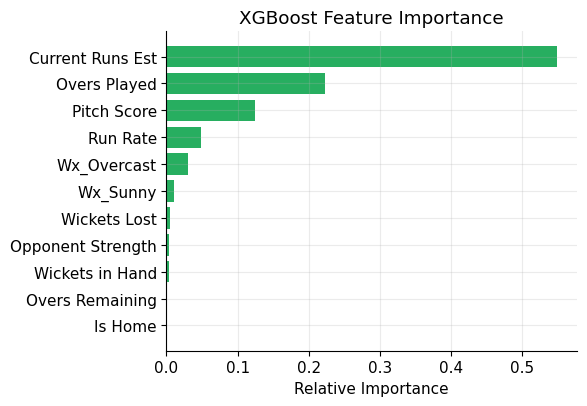

In [25]:
fig, ax = plt.subplots(figsize=(6, 4.2))
imp_sorted = imp.sort_values()
ax.barh(imp_sorted.index, imp_sorted.values, color="#27ae60")
ax.set_title("XGBoost Feature Importance")
ax.set_xlabel("Relative Importance")
plt.tight_layout()
plt.show()

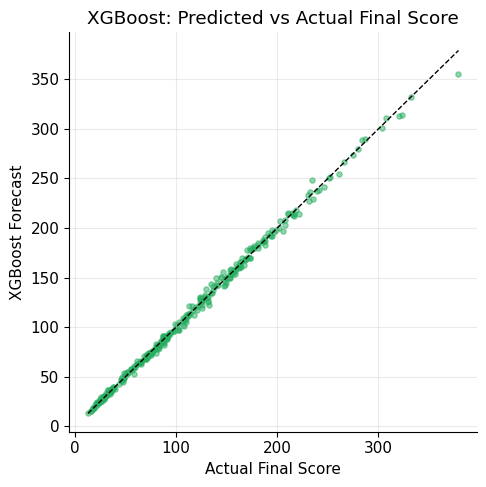

In [26]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, xgb_forecast, alpha=0.5, s=14, color="#27ae60")
lims = [min(y_test.min(), xgb_forecast.min()), max(y_test.max(), xgb_forecast.max())]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Actual Final Score")
ax.set_ylabel("XGBoost Forecast")
ax.set_title("XGBoost: Predicted vs Actual Final Score")
plt.tight_layout()
plt.show()